# Walmart Analysis

- **Problem Type**: Regression
- **Evaluation Metric**: RMSE
- **Models to test**:
  - Machine Learning
    - Linear Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Regressor
    - Random Forest Regressor
    - Support Vector Regressor
    - KNearestNeighbour Regressor
  - Boosting
    - XGBoost Regressor
    - LightGBM Regressor
  - Deep Learning
    - Artificial Neural Network

## Brief Description of dataset: 
One of the leading retail stores in the US, Walmart, would like to predict the sales and demand accurately. There are certain events and holidays which impact sales on each day. There are sales data available for 45 stores of Walmart. The business is facing a challenge due to unforeseen demands and runs out of stock some times, due to the inappropriate machine learning algorithm. An ideal ML algorithm will predict demand accurately and ingest factors like economic conditions including CPI, Unemployment Index, etc.

**Problem Statement**: Build Regression models to predict the sales w.r.t single & multiple features.

## Loading Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import joblib

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [2]:
df_og = pd.read_csv("Walmart.csv")
df_og.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## EDA

### Basic Information

In [3]:
df_og.shape

(6435, 8)

The dataset has 8 features each containing 6435 values

In [4]:
df_og.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


- Store - the store number
- Date - the week of sales
- Weekly_Sales - sales for the given store
- Holiday_Flag - whether the week is a special holiday week 1 – Holiday week 0 – Non-holiday week
- Temperature - Temperature on the day of sale
- Fuel_Price - Cost of fuel in the region
- CPI – Prevailing consumer price index
- Unemployment - Prevailing unemployment rate

### Handling Null Values

In [5]:
df_og.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Statistics of data

In [6]:
df_og.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


- Store column is discreet numerical feature
- 50% of the stores are generating from 553335 to 1420159 dollars per week
- Holiday flag seems to be a categorical column where
  - 0 - no holiday in week
  - 1 - holiday in week
  - This could be useful as well because weeks with holidays generally gets more sales
- 50% of the places where walmart stores are have 2.93 upto 3.73 dollars per gallon of fuel, and many walmarts have gas stations so this can also be a factor
- 50% of the time, the temprature on sales day is between 47.4 F to 74.9 F
- CPI ranges from 126 to 227, with 50% of them being in between 131 to 212
- 50% of the stores have unemployment rate of 6.9 to 8.62

In [7]:
df_og[df_og.select_dtypes(["object"]).columns].describe(include="all")

,Date
count,6435
unique,143
top,05-02-2010
freq,45


### Visualisation

In [8]:
def eda_plots(df, target=None):
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical_cols = df.select_dtypes(include="number").columns.tolist()

    if target:
        if target in categorical_cols:
            categorical_cols.remove(target)
            target_type = "categorical"
        elif target in numerical_cols:
            numerical_cols.remove(target)
            target_type = "numerical"
        else:
            raise ValueError(f"Target '{target}' not found in dataframe.")

    print("=" * 50)
    print("UNIVARIATE ANALYSIS")
    print("=" * 50)

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].axvline(
                df[col].mean(), color="r", linestyle="dashed", linewidth=1.5
            )
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if categorical_cols:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(categorical_cols):
            val_counts = df[col].value_counts()
            if len(val_counts) > 5:
                top = val_counts.head(5)
                top["Others"] = val_counts[5:].sum()
            else:
                top = val_counts

            axes[i].pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if target:
        print("\n" + "=" * 50)
        print("🔹 BIVARIATE ANALYSIS (Feature vs Target)")
        print("=" * 50)

        if numerical_cols:
            n_cols = 3
            n_rows = math.ceil(len(numerical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(numerical_cols):
                if target_type == "categorical":
                    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
                else:
                    sns.scatterplot(data=df, x=col, y=target, alpha=0.5, ax=axes[i])
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

        if categorical_cols:
            n_cols = 3
            n_rows = math.ceil(len(categorical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(categorical_cols):
                if target_type == "categorical":
                    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
                else:
                    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
                axes[i].tick_params(axis="x", rotation=45)
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

    print("\n" + "=" * 50)
    print("🔹 MULTIVARIATE ANALYSIS")
    print("=" * 50)

    num_df = df.select_dtypes(include=["number"])
    if num_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr = num_df.corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Heatmap")
        plt.show()

UNIVARIATE ANALYSIS


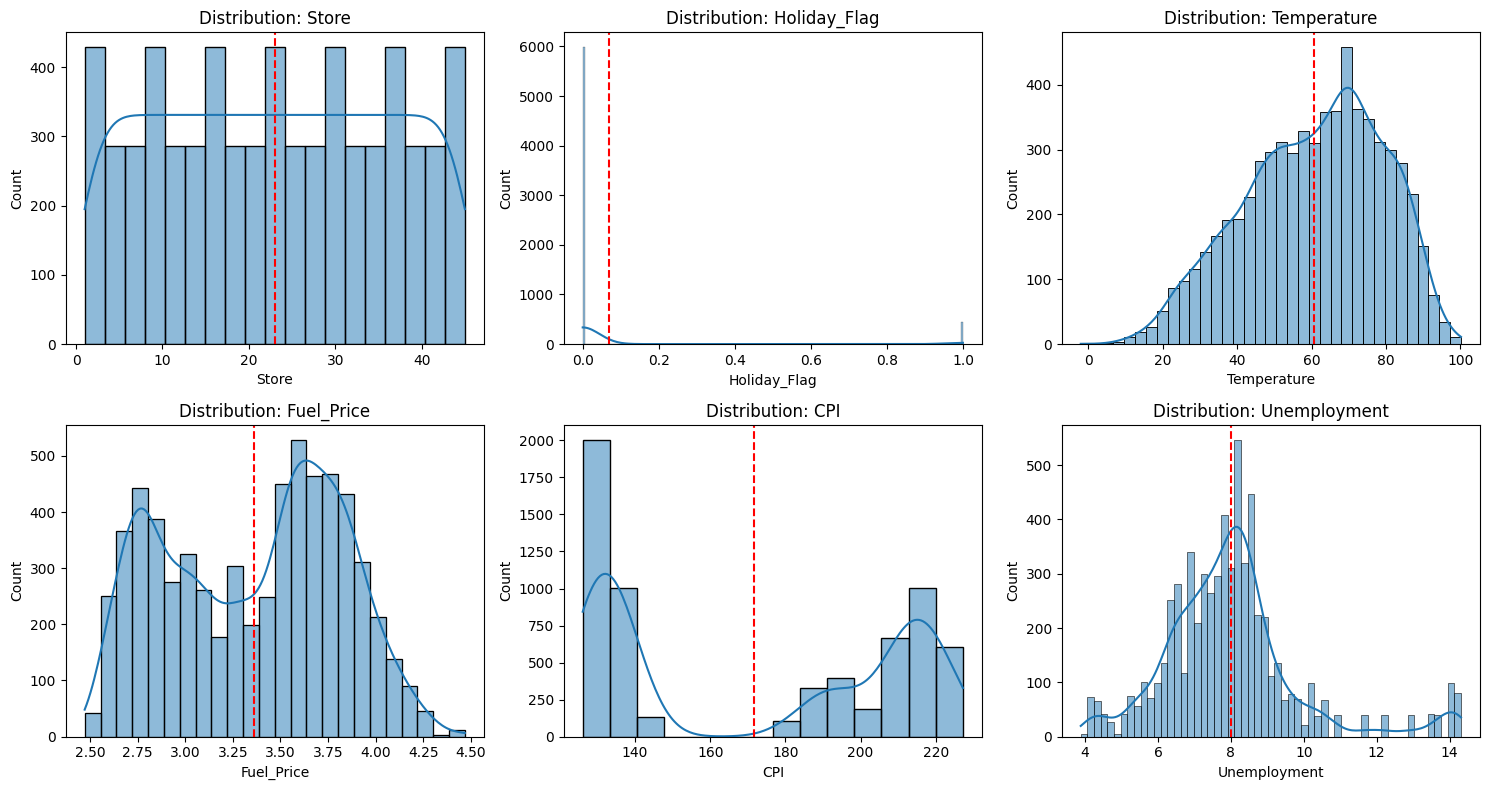

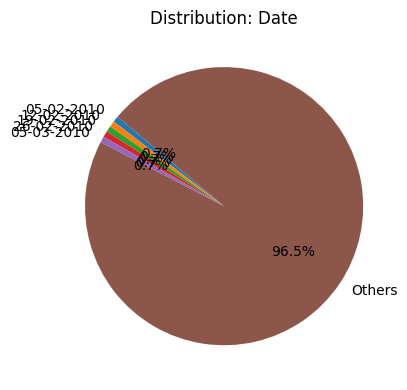


🔹 BIVARIATE ANALYSIS (Feature vs Target)


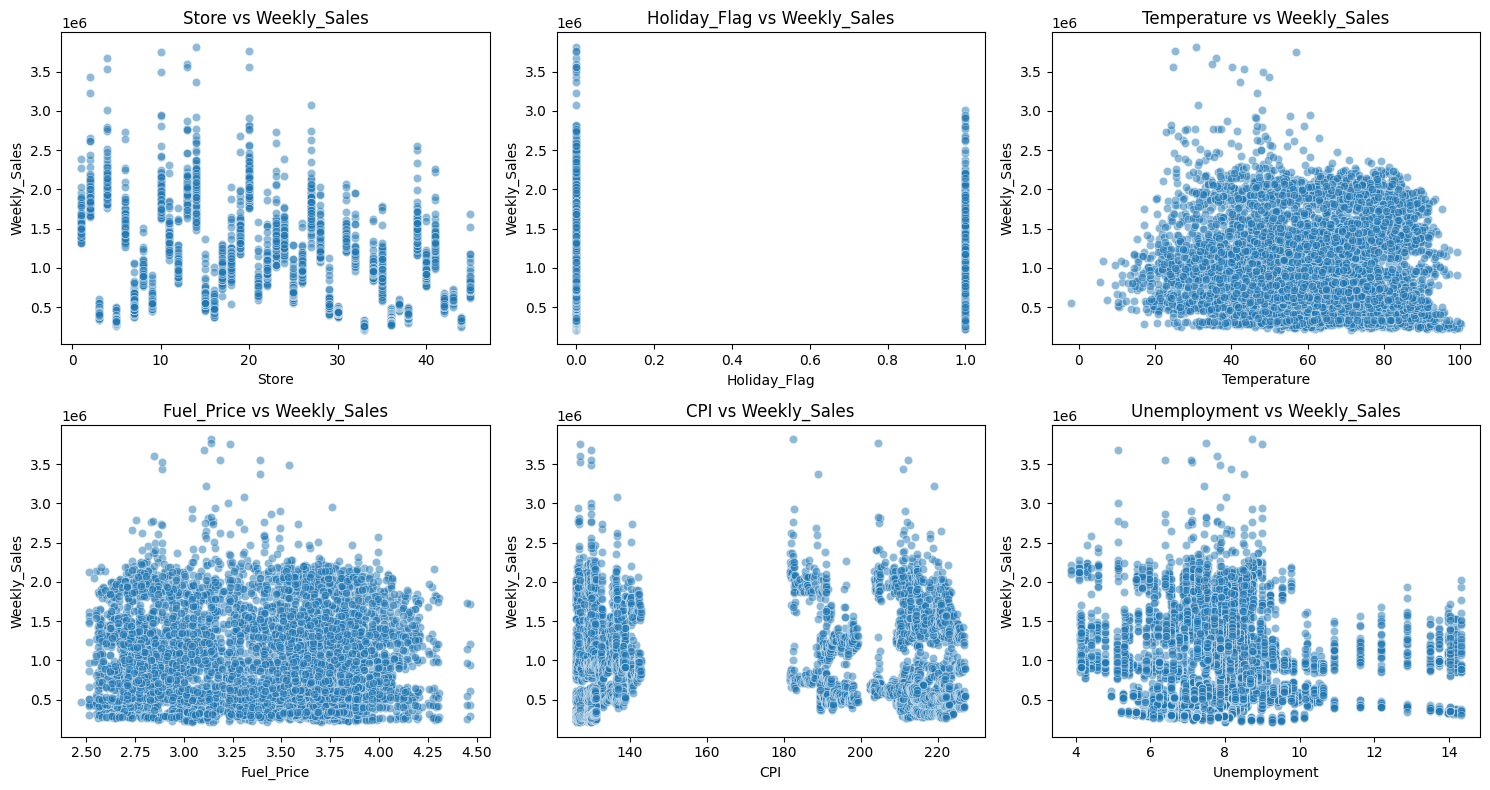

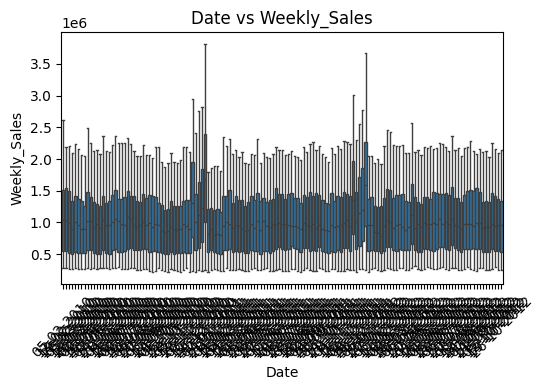


🔹 MULTIVARIATE ANALYSIS


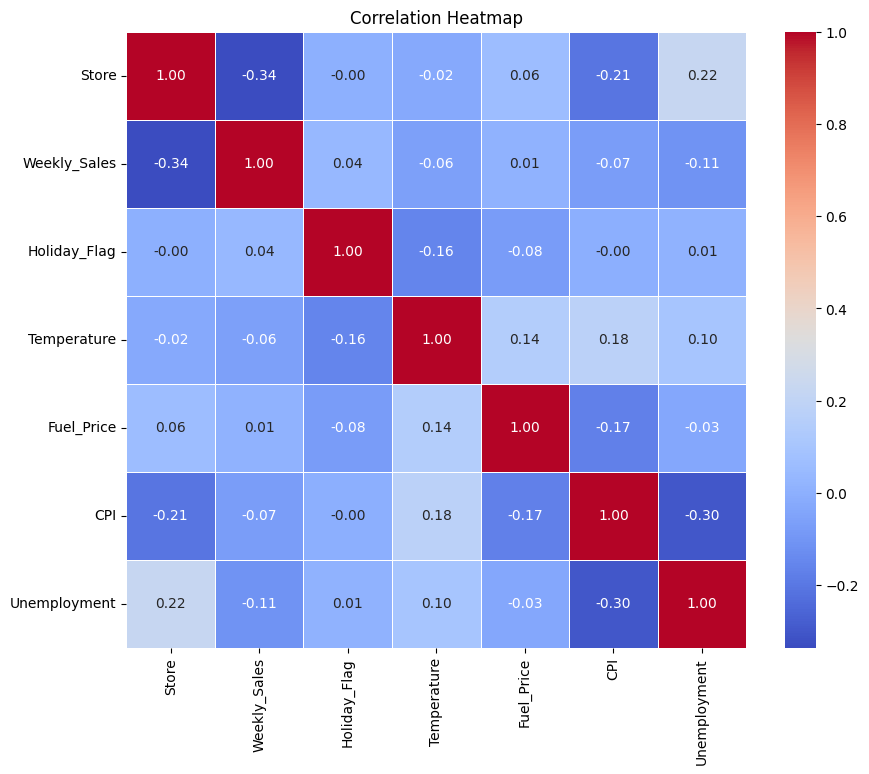

In [9]:
target = "Weekly_Sales"

eda_plots(df_og, target)

#### Conclusion
Weekly sales are driven by categorical factors (Store ID, seasonality) rather than continuous macroeconomic variables.

1. Univariate Analysis
   - **Store**: Exhibits a perfectly uniform distribution across 45 locations.
   - **Date**: Highly granular time-series variable with 96.5% unique entries.
   - **Macro Variables**: CPI and Fuel Price are bimodal; Temperature and Unemployment are normally distributed.
   - **Holidays**: Highly imbalanced, consisting almost entirely of non-holiday weeks.

2. Bivariate Analysis
   - **Store Impact**: Store ID dictates base sales volume and revenue ceilings.
   - **Temporal Spikes**: Specific dates show massive, isolated holiday revenue spikes.
   - **Macro Impact**: Temperature, Fuel, CPI, and Unemployment show no linear relationship with sales.

3. Multivariate Analysis
   - **Weak Predictors**: Macroeconomic indicators have near-zero linear correlation with Weekly_Sales.
   - **False Correlation**: Store shows a -0.34 correlation with sales, but this is meaningless as it's a nominal category.
   - **Collinearity**: Unemployment and CPI have a mild negative correlation (-0.30), posing no multicollinearity risk.

Modeling Recommendations
   - **Data Types**: Cast `Store` as a categorical/string variable.
   - **Feature Engineering**: Extract `Month` and `Week_of_Year` from the `Date` column.

### Target Feature Analysis - Sales

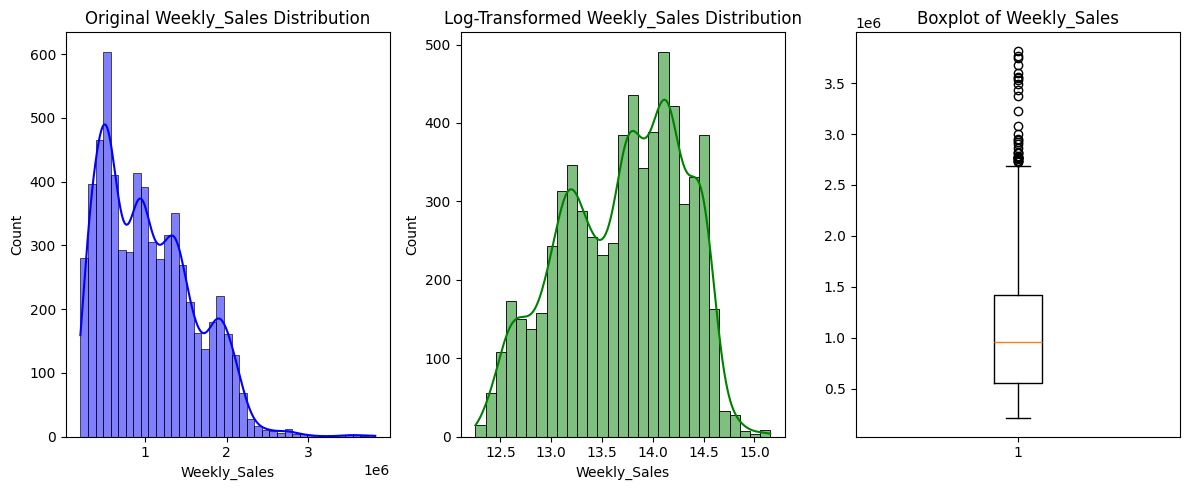

In [10]:
target = "Weekly_Sales"

plt.figure(figsize=(12, 5))

# Plot 1: Standard Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_og[target], kde=True, color="blue")
plt.title(f"Original {target} Distribution")

# Plot 2: Log Transformed Distribution
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_og[target]), kde=True, color="green")
plt.title(f"Log-Transformed {target} Distribution")

# Plot 2: Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df_og[target])
plt.title(f"Boxplot of {target}")

plt.tight_layout()
plt.show()

- **Distribution**: The target follows a right-skewed distribution with a primary peak around 0.5M–1M and a long tail extending toward 3.5M+.
  - Log transformed Weekly_sales is much distributed much better.
- **Outliers**: The boxplot confirms a significant number of high-value outliers above the 2.5M mark, representing exceptional sales weeks.
- **Volume**: Most weekly records are concentrated between 0.5M and 1.5M, as indicated by the interquartile range (IQR).

## Feature engineering

In [11]:
def engineer_features(df):
    df_eng = df.copy()

    df_eng["Date"] = pd.to_datetime(df_eng["Date"], format="%d-%m-%Y")

    df_eng["Year"] = df_eng["Date"].dt.year
    df_eng["Month"] = df_eng["Date"].dt.month
    df_eng["Week_of_Year"] = df_eng["Date"].dt.isocalendar().week.astype(int)

    df_eng["Store"] = df_eng["Store"].astype(str)
    
    df_eng["Holiday_Flag"] = df_eng["Holiday_Flag"].astype(str)

    df_eng["Log_Weekly_Sales"] = np.log1p(df_eng["Weekly_Sales"])

    df_eng = df_eng.drop(columns=["Date"])

    return df_eng

In [12]:
df = engineer_features(df_og)
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week_of_Year,Log_Weekly_Sales
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,14.312455
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,14.311400
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,14.292967
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,14.158908
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,14.256862


In [13]:
target = "Log_Weekly_Sales"

## Feature selection

In [14]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'Week_of_Year', 'Log_Weekly_Sales'],
      dtype='object')
categorical cols: Index(['Store', 'Holiday_Flag'], dtype='object')


### VIF for numerical columns

In [15]:
num_cols = df.select_dtypes(include="number").columns
X_num = df[num_cols].drop([target, "Weekly_Sales"], axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))
]
print(vif_data)

        Feature         VIF
0   Temperature   13.991817
1    Fuel_Price   60.572925
2           CPI   24.597521
3  Unemployment   22.134928
4          Year  144.650919
5         Month  628.417951
6  Week_of_Year  548.492110


### MIR for Categorical columns

In [16]:
X_cat = df.select_dtypes(include=["object", "category", "bool"])

oe = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(
    oe.fit_transform(X_cat.astype(str)), columns=X_cat.columns, index=X_cat.index
)

mi_scores = mutual_info_regression(X_cat_encoded, df[target])

mi_results = pd.DataFrame(
    {"Feature": X_cat.columns, "MI Score": mi_scores}
).sort_values(by="MI Score", ascending=False)

print(mi_results)

        Feature  MI Score
0         Store  1.719414
1  Holiday_Flag  0.004206


### Conclusion:

- We will drop Month becuase Week_of_Year is much better indication
- We will also drop Weekly_Sales because we will be targeting Log_Weekly_Sales and applying an inverse transformation during evaluation
- Holiday_Flag might have a small score but that's because it is very imbalanced feature

### Final Cleaned Dataset Creation

In [17]:
columns_to_drop = ["Weekly_Sales", "Month"]

df_final = df.drop(columns=columns_to_drop)

df_final.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Week_of_Year,Log_Weekly_Sales
0,1,0,42.31,2.572,211.096358,8.106,2010,5,14.312455
1,1,1,38.51,2.548,211.242170,8.106,2010,6,14.311400
2,1,0,39.93,2.514,211.289143,8.106,2010,7,14.292967
3,1,0,46.63,2.561,211.319643,8.106,2010,8,14.158908
4,1,0,46.50,2.625,211.350143,8.106,2010,9,14.256862


In [18]:
path = "Walmart_cleaned.csv"

df_final.to_csv(path)

print(f"Saved df_final to \"{path}\"")

Saved df_final to "Walmart_cleaned.csv"


### Input - Target Split

In [19]:
X = df_final.drop(target, axis = 1)
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6435, 8)
y shape: (6435,)


## Train - Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (5148, 8)
y_train Shape: (5148,)
X_test Shape: (1287, 8)
y_test Shape: (1287,)


## Preprocessors

In [21]:
# 1. Define feature groups
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LogReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

## Defining Pipelines

In [22]:
ml_models = {
    "Linear Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LinearRegression())]
    ),
    "SVR": Pipeline([("pre", linear_preprocessor), ("clf", SVR())]),
    "KNN": Pipeline(
        [("pre", linear_preprocessor), ("clf", KNeighborsRegressor())]
    ),
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeRegressor(random_state=42))]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestRegressor(random_state=42))]
    ),
    "XGBoost": Pipeline(
        [("pre", tree_preprocessor), ("clf", XGBRegressor(random_state=42))]
    ),
    "LightGBM": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", LGBMRegressor(verbose=-1, random_state=42)),
        ]
    ),
}

## Training the Pipelines

In [23]:
results_list = []

for name, model in ml_models.items():
    # Train the model on the log-transformed data
    model.fit(X_train, y_train)

    # Model outputs predictions in log scale
    log_pred = model.predict(X_test)

    # Reverse the log transformation for BOTH actuals and predictions
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(log_pred)

    # Calculate metrics on the actual dollar amounts
    rmse = root_mean_squared_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    results_list.append({"Model": name, "RMSE": rmse, "R2": r2})
    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="R2", ascending=False)
display(ML_Results)

Training done for Linear Regression
Training done for SVR
Training done for KNN
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,RMSE,R2
5,XGBoost,76703.695820,0.981737
6,LightGBM,79578.936509,0.980342
4,Random Forest,125663.847984,0.950982
1,SVR,136483.399482,0.942178
2,KNN,147788.873542,0.932202
0,Linear Regression,152253.906783,0.928043
3,Decision Tree,156870.823945,0.923613


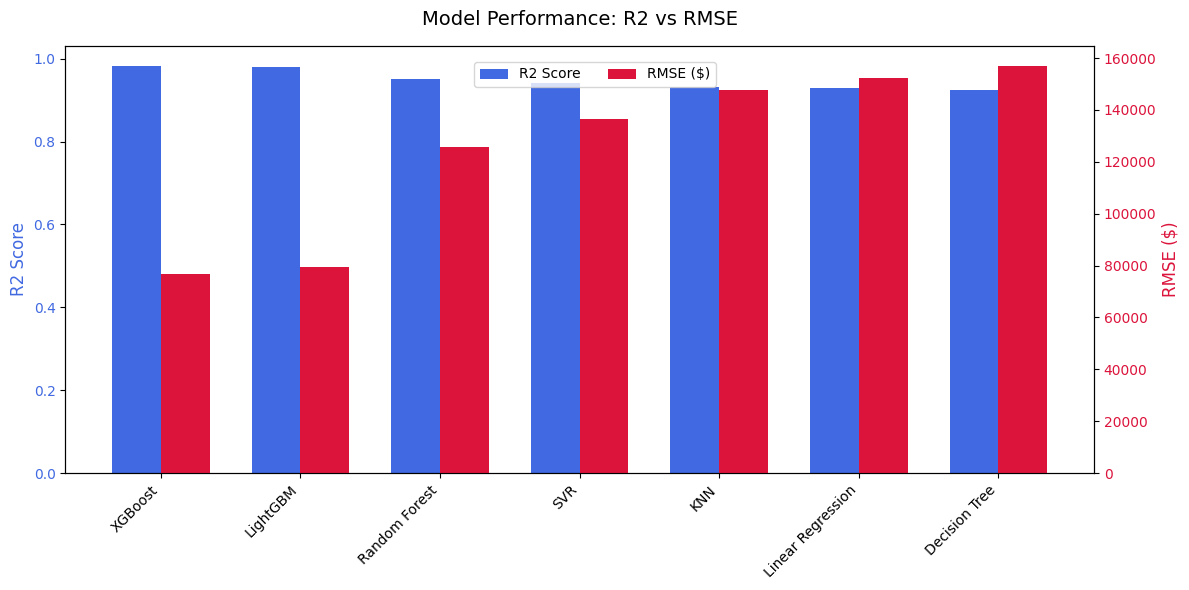

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(ML_Results["Model"]))
width = 0.35

bars1 = ax1.bar(
    x - width / 2, ML_Results["R2"], width, label="R2 Score", color="royalblue"
)
ax1.set_ylabel("R2 Score", color="royalblue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="royalblue")

ax1.set_xticks(x)
ax1.set_xticklabels(ML_Results["Model"], rotation=45, ha="right")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2, ML_Results["RMSE"], width, label="RMSE ($)", color="crimson"
)
ax2.set_ylabel("RMSE ($)", color="crimson", fontsize=12)
ax2.tick_params(axis="y", labelcolor="crimson")

plt.title("Model Performance: R2 vs RMSE", fontsize=14, pad=15)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), ncol=2)

plt.tight_layout()
plt.show()

Both XGBoost and LightGBM are capturing almost same amounts of Variance as indicated by their R2 score, but XGBoost has much better RMSE than LightGBM, so we will do hyperparameter tuning on XGBoost

## Hyperparameter Tuning

In [25]:
xgb_pipeline = Pipeline(
    [
        ("pre", tree_preprocessor),
        ("clf", XGBRegressor(tree_method="hist", device="cuda", random_state=42)),
    ]
)

param_distributions = {
    "clf__n_estimators": [100, 300, 500, 800],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [5, 7, 9, 12],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# Fit the search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {random_search.best_params_}")

best_xgb = random_search.best_estimator_
best_xgb

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'clf__subsample': 0.8, 'clf__n_estimators': 500, 'clf__min_child_weight': 5, 'clf__max_depth': 7, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 1.0}


Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  Index(['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year',
       'Week_of_Year'],
      dtype='object')),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Store', 'Holiday_Flag'], dtype='object'))])),
                ('clf',
                 XGBRegressor(base_scor...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=500,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [26]:
log_pred_xgb = best_xgb.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real_xgb = np.expm1(log_pred_xgb)

r2_xgb = r2_score(y_test_real, y_pred_real_xgb)

rmse_xgb = root_mean_squared_error(y_test_real, y_pred_real_xgb)

print("=" * 40)
print(f"Best XGB pipeline Score")
print(f"R2 Score: {r2_xgb}")
print(f"RMSE    : {rmse_xgb}")
print("=" * 40)

Best XGB pipeline Score
R2 Score: 0.9835837193500856
RMSE    : 72722.62196647172


With Hyperparamter tuning, we went from 98.1% R2 & 76K RMSE to 98.35% R2 & 72K

Our Neural Network would have to beat this in order to justify the higher inference cost.

## Neural Network

In [27]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]

In [28]:
# Setup
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = ["Adam", "RMSprop", "SGD"]
learning_rates = [0.1, 0.01, 0.001, 0.0001]
batch_sizes = [128, 256, 512]

# Standard KFold for continuous target
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Model
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            Dense(128, activation="relu", input_shape=(input_shape,)),
            Dropout(0.2),
            Dense(64, activation="relu"),
            Dense(1, activation="linear"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.SGD(learning_rate=lr, clipnorm=1.0)

    model.compile(
        loss="mean_squared_error",
        optimizer=opt,
    )
    return model

# Training Loop
cv_results_list = []
print("Starting 3-Fold CV Search for Regression...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_rmses = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_nn)):
                X_fold_train, X_fold_val = X_train_nn[train_idx], X_train_nn[val_idx]
                y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

                model = build_model(input_shape, opt_name, lr)

                es = EarlyStopping(
                    monitor="val_loss", patience=12, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=60,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                )

                # Predict in log scale
                y_pred_log = model.predict(X_fold_val, verbose=0).flatten()

                # Reverse the log transformation for both actuals and predictions
                y_fold_val_real = np.expm1(y_fold_val)
                y_pred_real = np.expm1(y_pred_log)

                # Calculate real-dollar RMSE
                fold_rmse = root_mean_squared_error(y_fold_val_real, y_pred_real)
                fold_rmses.append(fold_rmse)

            mean_rmse = np.mean(fold_rmses)
            std_rmse = np.std(fold_rmses)

            print(
                f"Config: {config_name:25} | Mean RMSE: ${mean_rmse:,.0f} | Std: ${std_rmse:,.0f}"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean RMSE": mean_rmse,
                    "Std": std_rmse,
                }
            )

CV_Results = pd.DataFrame(cv_results_list).sort_values(by="Mean RMSE", ascending=True)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS")
print("=" * 40)
display(CV_Results.head(5))

Starting 3-Fold CV Search for Regression...
-----------------------------------------------------------------
Config: Adam_LR0.1_BS128          | Mean RMSE: $168,010 | Std: $18,776
Config: Adam_LR0.1_BS256          | Mean RMSE: $192,663 | Std: $4,620
Config: Adam_LR0.1_BS512          | Mean RMSE: $330,941 | Std: $150,166
Config: Adam_LR0.01_BS128         | Mean RMSE: $167,966 | Std: $20,669
Config: Adam_LR0.01_BS256         | Mean RMSE: $204,854 | Std: $5,599
Config: Adam_LR0.01_BS512         | Mean RMSE: $219,686 | Std: $15,772
Config: Adam_LR0.001_BS128        | Mean RMSE: $220,290 | Std: $6,974
Config: Adam_LR0.001_BS256        | Mean RMSE: $262,568 | Std: $8,826
Config: Adam_LR0.001_BS512        | Mean RMSE: $389,952 | Std: $34,506
Config: Adam_LR0.0001_BS128       | Mean RMSE: $1,142,979 | Std: $189,922
Config: Adam_LR0.0001_BS256       | Mean RMSE: $4,970,282 | Std: $1,233,534
Config: Adam_LR0.0001_BS512       | Mean RMSE: $1,150,056 | Std: $12,643
Config: RMSprop_LR0.1_BS128    

,Optimizer,LR,BS,Mean RMSE,Std
3,Adam,0.010,128,167966.454428,20669.011105
0,Adam,0.100,128,168010.292833,18776.153102
15,RMSprop,0.010,128,182706.083406,11003.437909
1,Adam,0.100,256,192662.690097,4619.864713
18,RMSprop,0.001,128,195963.587113,6891.755685


Even though RMSprop has the best Mean RMSE, it has quite high std, so the best should be considered Adam, in conclusion

Our best
- **Optimiser**: Adam
- **Learning rate**: `0.01`

So we will build it and check the Training & Validation Loss curve and RMSE.


Training Final Model with Adam, LR: 0.01, Batch: 128...
Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 68.5987 - val_loss: 2.5245 - learning_rate: 0.0100
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7737 - val_loss: 0.3739 - learning_rate: 0.0100
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2677 - val_loss: 0.1696 - learning_rate: 0.0100
Epoch 4/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9721 - val_loss: 0.1681 - learning_rate: 0.0100
Epoch 5/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8506 - val_loss: 0.1330 - learning_rate: 0.0100
Epoch 6/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7587 - val_loss: 0.2229 - learning_rate: 0.0100
Epoch 7/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7523 - val_loss: 0.1530 - learning_rate: 0.0100
Epoch 8/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7212 - val_loss: 0.1188 - learning_rate: 0.0100
Epoch 9/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.703

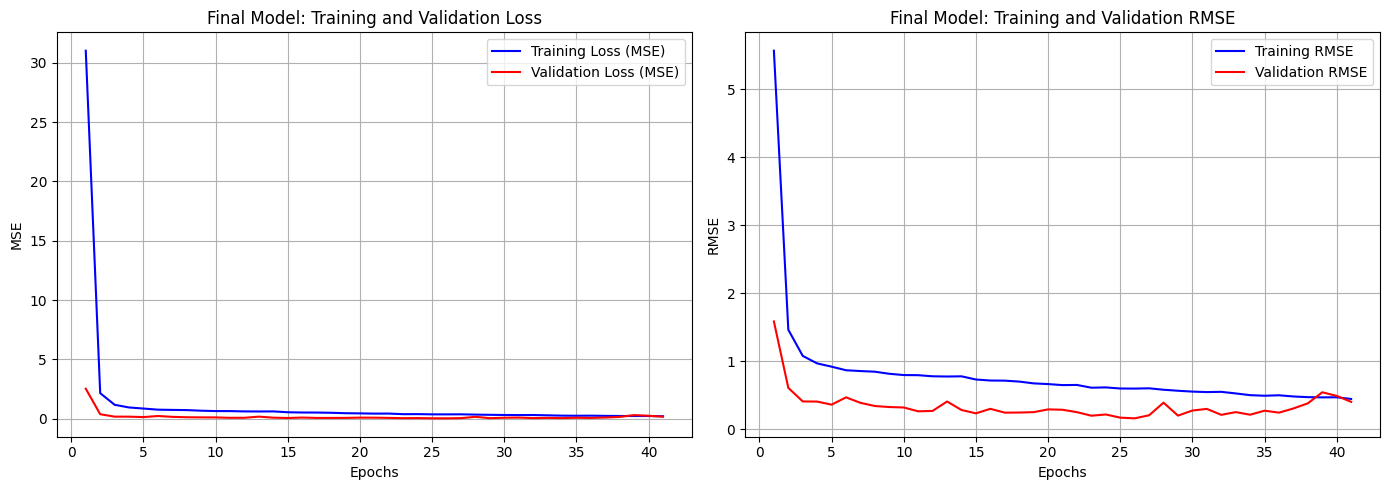

In [29]:
# ---------------------------------------------------------
# 5. EXECUTE FINAL TRAINING
# ---------------------------------------------------------
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

keras.backend.clear_session()
final_model = build_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
)

def plot_final_performance(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Calculate log-scale RMSE directly from the MSE loss
    rmse = np.sqrt(loss)
    val_rmse = np.sqrt(val_loss)

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss (MSE)")
    plt.plot(epochs, val_loss, "r", label="Validation Loss (MSE)")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # RMSE Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, rmse, "b", label="Training RMSE")
    plt.plot(epochs, val_rmse, "r", label="Validation RMSE")
    plt.title("Final Model: Training and Validation RMSE")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_final_performance(final_history)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Final Production Regression Metrics ---
Neural Network RMSE: 241613.4831
Neural Network R2:   0.8188


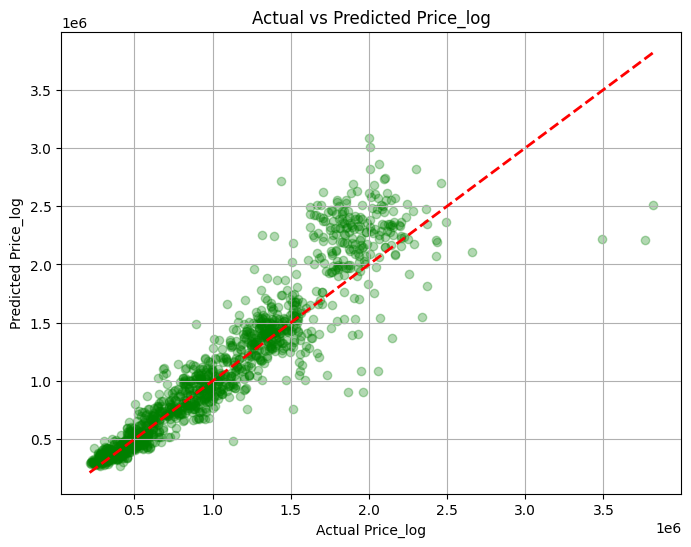

In [30]:
y_pred_nn = final_model.predict(X_test_nn).flatten()

y_test_real = np.expm1(y_test)
y_pred_nn = np.expm1(y_pred_nn)

final_rmse = root_mean_squared_error(y_test_real, y_pred_nn)
final_r2 = r2_score(y_test_real, y_pred_nn)

print("\n--- Final Production Regression Metrics ---")
print(f"Neural Network RMSE: {final_rmse:.4f}")
print(f"Neural Network R2:   {final_r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_nn, alpha=0.3, color="green")
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], "r--", lw=2)
plt.title("Actual vs Predicted Price_log")
plt.xlabel("Actual Price_log")
plt.ylabel("Predicted Price_log")
plt.grid(True)
plt.show()

## Comparison between the best Neural Network & best XGB & LightGBM

In [31]:
nn_log_pred = final_model.predict(X_test_nn, verbose=0).flatten()
nn_pred_real = np.expm1(nn_log_pred)

lgbm_log_pred = ml_models["LightGBM"].predict(X_test)
lgbm_pred_real = np.expm1(lgbm_log_pred)

xgb_log_pred = best_xgb.predict(X_test)
xgb_pred_real = np.expm1(xgb_log_pred)

final_results = [
    {
        "Model": "Tuned XGBoost",
        "RMSE ($)": root_mean_squared_error(y_test_real, xgb_pred_real),
        "R2 Score": r2_score(y_test_real, xgb_pred_real),
    },
    {
        "Model": "Baseline LightGBM",
        "RMSE ($)": root_mean_squared_error(y_test_real, lgbm_pred_real),
        "R2 Score": r2_score(y_test_real, lgbm_pred_real),
    },
    {
        "Model": "Deep Neural Network",
        "RMSE ($)": root_mean_squared_error(y_test_real, nn_pred_real),
        "R2 Score": r2_score(y_test_real, nn_pred_real),
    },
]

Final_Leaderboard = pd.DataFrame(final_results).sort_values(
    by="RMSE ($)", ascending=True
)

print("=" * 50)
print("FINAL TEST SET LEADERBOARD")
print("=" * 50)
display(Final_Leaderboard)

FINAL TEST SET LEADERBOARD


,Model,RMSE ($),R2 Score
0,Tuned XGBoost,72722.621966,0.983584
1,Baseline LightGBM,79578.936509,0.980342
2,Deep Neural Network,241613.483116,0.818792


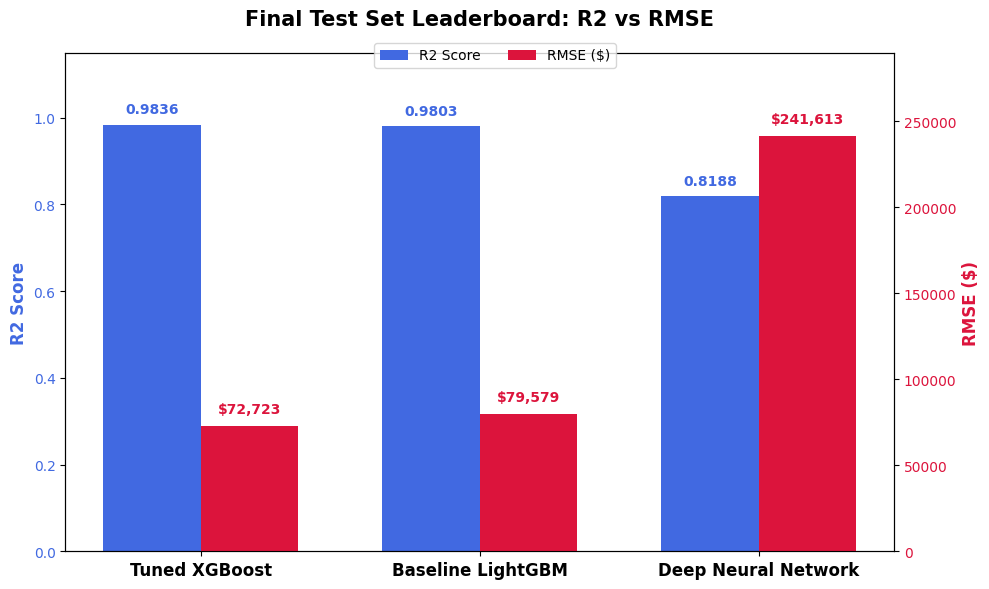

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(Final_Leaderboard["Model"]))
width = 0.35

bars1 = ax1.bar(
    x - width / 2,
    Final_Leaderboard["R2 Score"],
    width,
    label="R2 Score",
    color="royalblue",
)
ax1.set_ylabel("R2 Score", color="royalblue", fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.set_ylim(0, 1.15)  # Extra headroom for annotations

ax1.set_xticks(x)
ax1.set_xticklabels(Final_Leaderboard["Model"], fontsize=12, fontweight="bold")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    Final_Leaderboard["RMSE ($)"],
    width,
    label="RMSE ($)",
    color="crimson",
)
ax2.set_ylabel("RMSE ($)", color="crimson", fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, Final_Leaderboard["RMSE ($)"].max() * 1.2)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        color="royalblue",
        fontweight="bold",
        fontsize=10,
    )

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (ax2.get_ylim()[1] * 0.02),
        f"${yval:,.0f}",
        ha="center",
        va="bottom",
        color="crimson",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Final Test Set Leaderboard: R2 vs RMSE", fontsize=15, pad=20, fontweight="bold"
)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Our best Neural Network didn't even come close to the performance of Baseline LightGBM let alone Tuned XGBoost

# Conclusion

- XGBoost is the best model here with
  - **R2 Score**: 98%
  - **RMSE**    : 72,723 $

- **Why did traditional ML Outperforme ANN here:**
  - ANN are data hungry and lazy learner
  - ANNs starts with completely randomised weights and slowly learn pattern via feeding them lots of data
  - But here we only had 5400 rows for training and only 8 features
  - The ANN didn't have enough data to learn the patterns here
  - Whereas Traditional ML doesn't require that much data
  - if given enough data, ANN wouldv'e surpassed Tuned XGBoost easily but that isn't the case here.